In [17]:
import os

In [2]:
!pip install scikit-learn
!pip install matplotlib
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

import seaborn as sns

import pickle


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df = pd.read_csv(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\data\cleaned_complaints.csv"
)

In [6]:
X = df["clean_text"]

y = df["Agency Name"]

In [7]:
tfidf = TfidfVectorizer(

    max_features=5000,

    stop_words="english"
)

X_tfidf = tfidf.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,

    y,

    test_size=0.2,

    random_state=42
)

In [9]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = lr_model.predict(
    X_test
)

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9964189495267387


In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                                                    precision    recall  f1-score   support

                           Department of Buildings       1.00      1.00      1.00      5393
      Department of Consumer and Worker Protection       1.00      0.89      0.94       899
                           Department of Education       1.00      0.93      0.96       129
            Department of Environmental Protection       1.00      1.00      1.00      9816
           Department of Health and Mental Hygiene       1.00      0.99      1.00      3587
                   Department of Homeless Services       1.00      0.68      0.81      1569
Department of Housing Preservation and Development       1.00      1.00      1.00     66193
                Department of Parks and Recreation       1.00      0.99      1.00      3484
                          Department of Sanitation       1.00      1.00      1.00     23412
                      Department of Transportation       0.99      1.00      0.

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

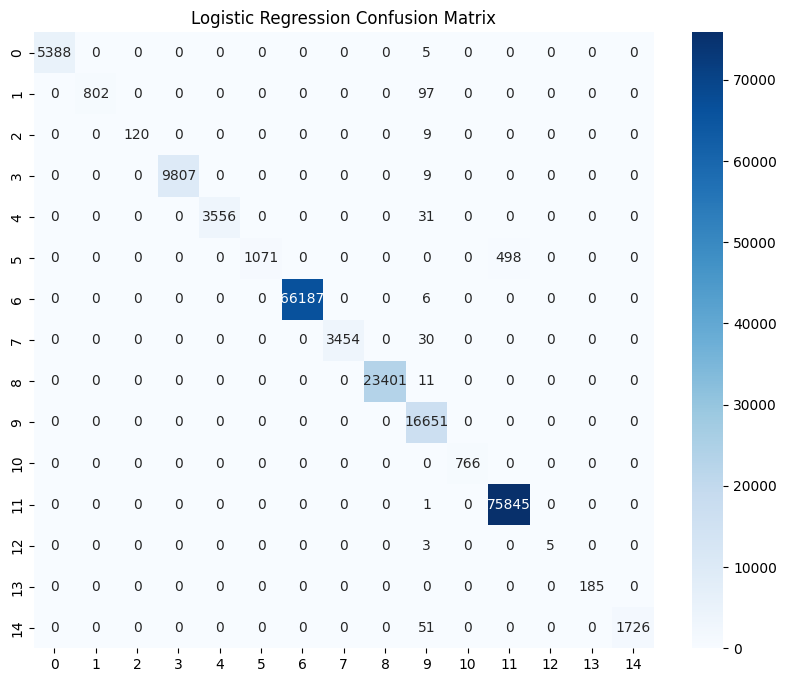

In [24]:
# Create outputs folder if it doesn't exist
os.makedirs("outputs", exist_ok=True)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

# Save plot
plt.savefig(
    "outputs/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)


In [25]:
with open(
    "models/logistic_regression.pkl",
    "wb"
) as file:

    pickle.dump(
        lr_model,
        file
    )

In [23]:
os.makedirs("models", exist_ok=True)

# Save model
with open(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models/logistic_regression.pkl",
    "wb"
) as file:

    pickle.dump(
        lr_model,
        file
    )

print("✅ Model saved successfully!")

✅ Model saved successfully!
